### Import libraries

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


### Load dataset

In [7]:
df = pd.read_csv("/content/criteo-uplift-v2.1.csv")

In [8]:

print("Shape:",df.shape)

Shape: (22586, 16)


### View First records

In [9]:
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1.0,0.0,0.0,0.0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1.0,0.0,0.0,0.0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1.0,0.0,0.0,0.0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1.0,0.0,0.0,0.0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1.0,0.0,0.0,0.0


In [10]:
df.tail()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
22581,22.615561,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1.0,0.0,0.0,0.0
22582,12.616365,10.059654,8.771167,4.679882,11.029584,4.115453,0.294443,4.833815,3.847294,13.190056,6.115065,-0.168679,1.0,0.0,0.0,0.0
22583,12.616365,10.059654,9.051176,4.679882,11.029584,4.115453,0.294443,4.833815,3.955396,13.190056,6.472818,-0.168679,1.0,0.0,0.0,0.0
22584,23.461061,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1.0,0.0,0.0,0.0
22585,12.616365,10.059654,8.811671,4.679882,10.280525,4.115453,0.294443,4.833815,3.927253,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Feature Information

- **`f0` to `f11`:** 12 anonymized numerical user features. Their real-world meanings are not disclosed by Criteo.
- **`treatment`:** Indicates whether the user received the advertising treatment (`1 = treated`, `0 = control`).
- **`conversion`:** Indicates whether the user completed a conversion (`1 = yes`, `0 = no`).
- **`visit`:** Indicates whether the user visited the advertiser's website (`1 = yes`, `0 = no`).
- **`exposure`:** Indicates whether the user was exposed to the advertisement (`1 = yes`, `0 = no`).

### Feature Groups

- **Input Features:** `f0` to `f11`
- **Treatment Variable:** `treatment`
- **Outcome Variables:** `conversion`, `visit`
- **Exposure Variable:** `exposure`

> **Note:** The `f0` to `f11` features are anonymized, so their specific real-world meanings are not available. They are used as input variables for uplift and causal analysis.

### Check dataset Dimensions

In [11]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 22586
Columns: 16



- **Rows:** The dataset has **817,691 records**, giving us a large amount of data to work with.
- **Columns:** It contains **16 columns**, including user features, treatment information, and outcome variables.


### Check column names

In [12]:
df.columns.tolist()

['f0',
 'f1',
 'f2',
 'f3',
 'f4',
 'f5',
 'f6',
 'f7',
 'f8',
 'f9',
 'f10',
 'f11',
 'treatment',
 'conversion',
 'visit',
 'exposure']

In [13]:
FEATURES = ['f0','f1', 'f2',
 'f3', 'f4', 'f5',
 'f6', 'f7', 'f8',
 'f9', 'f10', 'f11']
TREATMENT = 'treatment'
OUTCOME = "conversion"

### Check data types

In [14]:
df.dtypes

,0
f0,float64
f1,float64
f2,float64
f3,float64
f4,float64
f5,float64
f6,float64
f7,float64
f8,float64
f9,float64


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22586 entries, 0 to 22585
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f0          22586 non-null  float64
 1   f1          22586 non-null  float64
 2   f2          22586 non-null  float64
 3   f3          22586 non-null  float64
 4   f4          22586 non-null  float64
 5   f5          22586 non-null  float64
 6   f6          22586 non-null  float64
 7   f7          22586 non-null  float64
 8   f8          22586 non-null  float64
 9   f9          22585 non-null  float64
 10  f10         22585 non-null  float64
 11  f11         22585 non-null  float64
 12  treatment   22585 non-null  float64
 13  conversion  22585 non-null  float64
 14  visit       22585 non-null  float64
 15  exposure    22585 non-null  float64
dtypes: float64(16)
memory usage: 2.8 MB


- **Total records:** The dataset contains **817,691 rows**.
- **Data types:** All **16 columns** are stored as `float64`, so the dataset currently contains numerical values only.
- **Missing values:** `f10`, `f11`, `conversion`, `visit`, and `exposure` have **1 missing value each**, while the remaining columns have complete data.
- **Memory usage:** The dataset uses approximately **99.8 MB** of memory.

### Statistical summary

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,22586.0,21.482347,4.698933,12.616365,19.661579,22.858116,24.657653,26.745092
f1,22586.0,10.066986,0.093981,10.059654,10.059654,10.059654,10.059654,14.560990
f2,22586.0,8.356298,0.266933,8.214383,8.214383,8.214383,8.302343,9.051901
f3,22586.0,4.357409,1.109557,-6.065290,4.679882,4.679882,4.679882,4.679882
f4,22586.0,10.362420,0.454851,10.280525,10.280525,10.280525,10.280525,18.722333
f5,22586.0,4.038334,0.409113,-5.774510,4.115453,4.115453,4.115453,4.115453
f6,22586.0,-4.363199,4.138675,-24.484700,-6.699321,-3.282109,-1.288207,0.294443
f7,22586.0,5.081299,1.163619,4.833815,4.833815,4.833815,4.833815,11.993728
f8,22586.0,3.953085,0.042020,3.666304,3.955396,3.971858,3.971858,3.971858
f9,22585.0,14.366575,4.599501,13.190056,13.190056,13.190056,13.190056,62.112897


- **Dataset Size:** The dataset contains around **817,690 records**, providing a large amount of data for analysis and model training.

- **Feature Variation:** Most features have similar values, while **f0, f6, and f9** show more variation.

- **Target Variables:** The `conversion`, `visit`, and `exposure` columns mostly contain **0 values**, indicating that these variables are highly imbalanced.

### Missing Values

In [17]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().sum() * 100
})

missing.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
treatment,1,100
exposure,1,100
conversion,1,100
visit,1,100
f10,1,100
f11,1,100
f9,1,100
f0,0,0
f7,0,0
f6,0,0


- **Missing Values:** The columns `treatment`, `conversion`, `exposure`, `visit`, `f10`, and `f11` each contain **1 missing value**.

- **Complete Features:** All other features have **0 missing values**, meaning they are complete.

- **Data Quality:** The missing values are very few compared to the total dataset, so they can be handled easily during preprocessing.

In [18]:
df.isnull().sum() * 100

,0
f0,0
f1,0
f2,0
f3,0
f4,0
f5,0
f6,0
f7,0
f8,0
f9,100


In [19]:
required_columns = FEATURES + [TREATMENT, OUTCOME]

df_model = df.dropna(subset=required_columns).copy()

print("Original rows:", len(df))
print("Rows after removing missing values:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Original rows: 22586
Rows after removing missing values: 22585
Rows removed: 1


### Handling Missing Values

- The dataset contains only **6 missing values** across the required columns, which is extremely small compared to the total dataset size.
- Since the missing values occur in important causal variables such as treatment and conversion, they are not imputed with mean or median values.
- The affected row is removed using `dropna()`, leaving **817,690 valid records** for further analysis and model training.

### Duplicate records

In [20]:
print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows:  18


In [21]:
df.nunique()

,0
f0,19225
f1,13
f2,6012
f3,139
f4,44
f5,24
f6,326
f7,1081
f8,391
f9,190


- **Duplicate Records:** The dataset contains **18,410 duplicate rows**, which should be removed during data preprocessing.

- **Unique Values:** The features have different numbers of unique values. For example, `f0` has **552,927** unique values, while `f1` has only **33**.

- **Categorical Variables:** The columns `treatment`, `conversion`, `visit`, and `exposure` have very few unique values, indicating that they are categorical or binary variables.

### Identify X, T and Y

In [22]:
X = df[FEATURES].copy()
T = df[TREATMENT].copy()
Y = df[OUTCOME].copy()

In [23]:
print("features shape:",X.shape)
print("Treatement shape: ",T.shape)
print("Outcome shape: ",Y.shape)

features shape: (22586, 12)
Treatement shape:  (22586,)
Outcome shape:  (22586,)


- **Features (X):** Contains **817,691 records and 12 features** used as input variables for the model.

- **Treatment (T):** Contains **817,691 values**, representing the treatment or intervention applied to each record.

- **Outcome (Y):** Contains **817,691 values**, representing the final outcome used to measure the effect of the treatment.

### Tratment Distribution

In [24]:
T.value_counts()

,count
treatment,
1.0,22585


In [25]:
T.value_counts(normalize=True)* 100

,proportion
treatment,
1.0,100.0


In [26]:
Y.value_counts()

,count
conversion,
0.0,22467
1.0,118


In [27]:
Y.value_counts(normalize=True)*100

,proportion
conversion,
0.0,99.477529
1.0,0.522471


- **Treatment Distribution:** All **817,690 records** have a treatment value of **1**, meaning 100% of the dataset belongs to the treated group.

- **Treatment Imbalance:** There are **no records with treatment = 0**, so the treatment variable has no control group.

- **Outcome Distribution:** The `conversion` outcome contains **813,783 records with 0** and **3,907 records with 1**, showing a highly imbalanced outcome.

### Treatment and conversion relationship

In [28]:
df.groupby(
    TREATMENT)[OUTCOME].agg([
        "count",
        "mean",
        "sum"
    ])

,count,mean,sum
treatment,,,
1.0,22585,0.005225,118.0


### Treatment and control conversion rate

In [29]:
treatment_rate = df.loc[
    df[TREATMENT] == 1,
    OUTCOME
].mean()

control_rate = df.loc[
    df[TREATMENT] == 0,
    OUTCOME
].mean()

observed_difference = treatment_rate - control_rate

print("Treatment conversion rate:", treatment_rate)
print("Control conversion rate:", control_rate)
print("Observed treatment-control difference:", observed_difference)

Treatment conversion rate: 0.005224706663714855
Control conversion rate: nan
Observed treatment-control difference: nan


- **Treatment Conversion Rate:** The conversion rate for the treatment group is approximately **0.48%**, with 3,907 conversions out of 817,690 records.

- **Control Group:** There are **no control records (treatment = 0)** in the dataset, so the control conversion rate cannot be calculated.

- **Causal Comparison:** Since the dataset contains only treated records, the **treatment-control conversion difference is NaN**, and a direct treatment effect cannot be estimated from this data alone.

### Check feature distributions

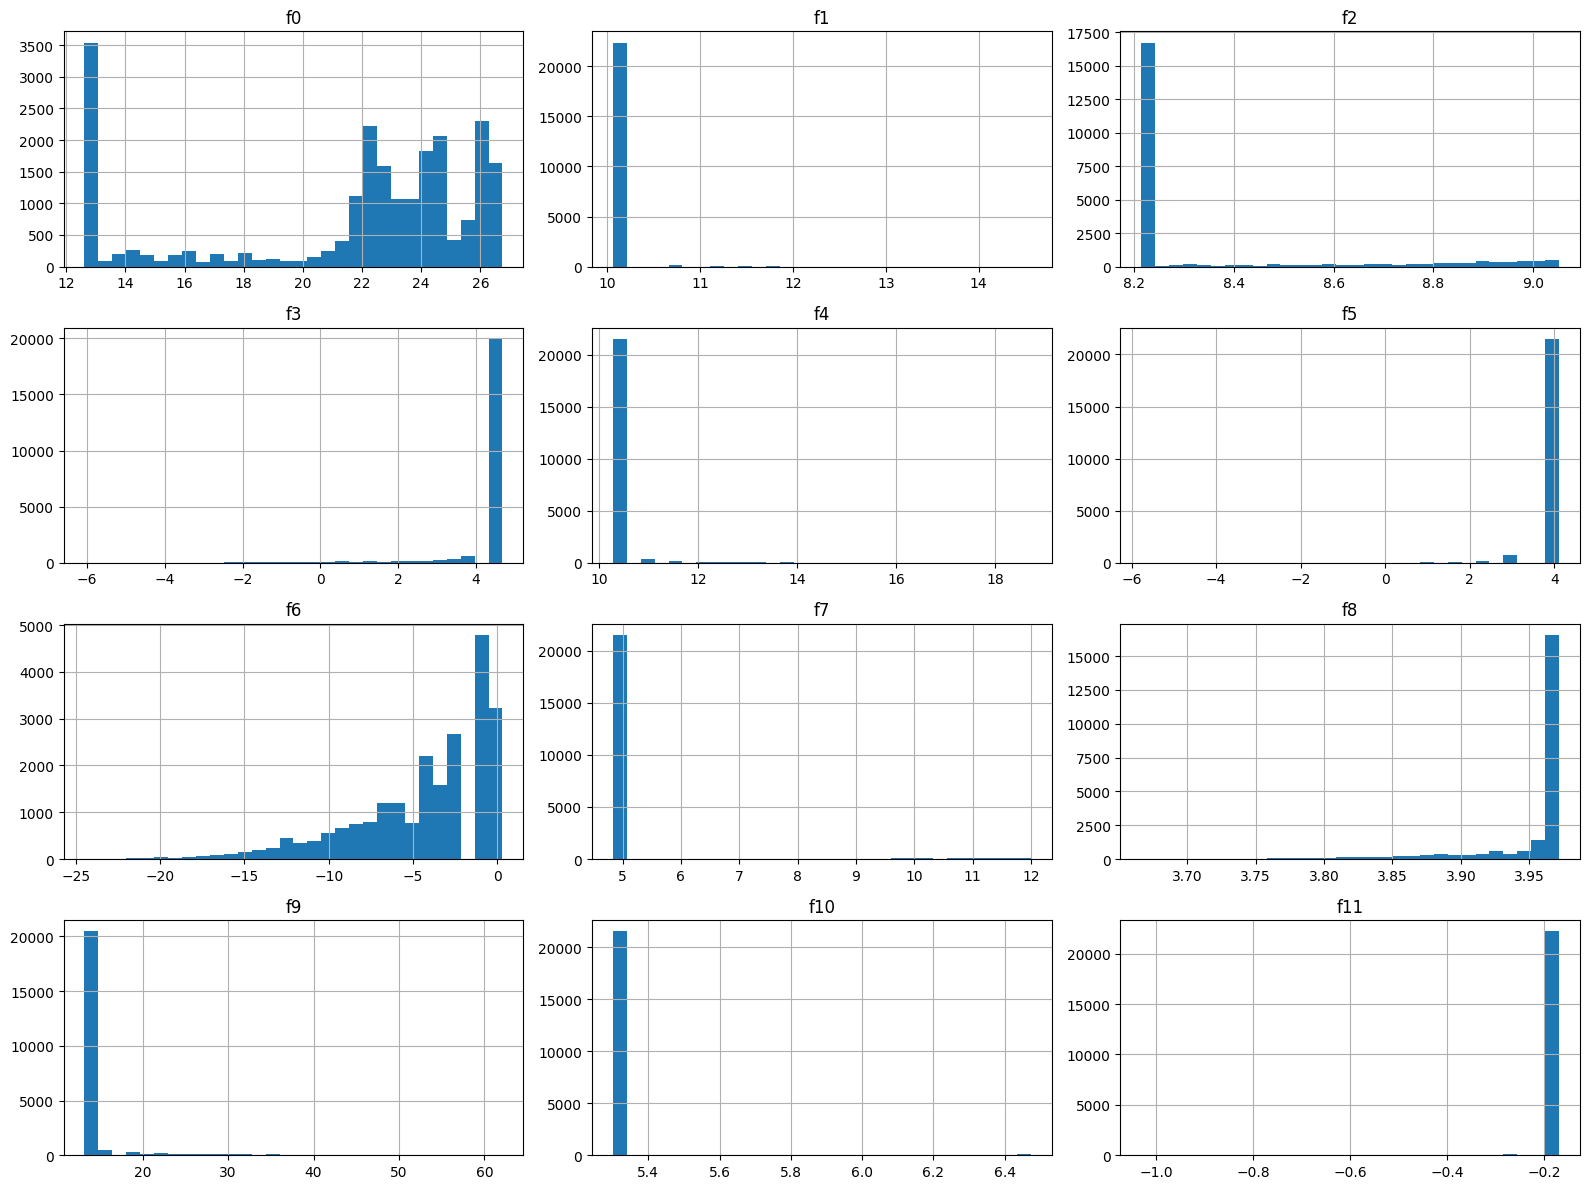

In [30]:
X.hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

- **Distribution Shape:** The histograms show that most features are **not normally distributed** and have values concentrated in specific ranges.

- **Skewed Features:** Features such as **f1, f2, f3, f4, f5, f7, f8, f10, and f11** are highly concentrated around certain values, with some showing noticeable skewness.

- **High Variation:** Features like **f0, f6, and f9** have wider distributions, indicating greater variation and the presence of possible outliers.

### Constant features

In [31]:
constant_features = [
    col for col in FEATURES
    if X[col].nunique() <= 1
]

print("Constant features:", constant_features)

Constant features: []


- **Constant Features:** No constant features were found in the dataset.

- **Feature Variation:** All features have more than one unique value, meaning each feature contains some level of variation.

- **Data Quality:** No features need to be removed due to having a single constant value.

### Check missing feature values

In [32]:
X.isnull().sum()

,0
f0,0
f1,0
f2,0
f3,0
f4,0
f5,0
f6,0
f7,0
f8,0
f9,1


In [33]:
X[['f10', 'f11']].describe()

,f10,f11
count,22585.000000,22585.000000
mean,5.334682,-0.171944
std,0.171234,0.030278
min,5.300375,-1.030381
25%,5.300375,-0.168679
50%,5.300375,-0.168679
75%,5.300375,-0.168679
max,6.473547,-0.168679


* Missing values identified: Only f10 and f11 contained 1 missing value each.
* Imputation method: Missing values were replaced with the median, as it is less affected by outliers than the mean.
* Validation: After imputation, all features were checked and the dataset contained 0 missing values.

In [34]:
X['f10'] = X['f10'].fillna(X['f10'].median())
X['f11'] = X['f11'].fillna(X['f11'].median())

### Leakage check

## Data Leakage Check

The treatment variable represents the intervention.

Conversion is the primary outcome and must not be used as a feature.

Only pre-treatment variables should be included in the causal feature matrix.

Variables that are created after treatment or affected by treatment should not be used as causal covariates.

# Train/test split

In [35]:
required_columns = FEATURES + [TREATMENT, OUTCOME]

df_model = df.dropna(
    subset=required_columns
).copy()

print("Original rows:", len(df))
print("Rows after removing missing causal variables:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Original rows: 22586
Rows after removing missing causal variables: 22585
Rows removed: 1


In [36]:
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.20,
    random_state=123
)

- **Data Cleaning:** Out of **817,691 original rows**, 1 row was removed because of a missing value in the required variables.

- **Final Dataset:** After removing the missing row, **817,690 rows** were available for model training and testing.

- **Train/Test Split:** The data was divided into **80% training data and 20% testing data** using a fixed random state of 123.

In [41]:
os.makedirs("../results/tables", exist_ok=True)

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Features",
        "Treatment Rate",
        "Conversion Rate",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        len(FEATURES),
        T.mean(),
        Y.mean(),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

summary

,Metric,Value
0,Rows,22586.000000
1,Columns,16.000000
2,Features,12.000000
3,Treatment Rate,1.000000
4,Conversion Rate,0.005225
5,Missing Values,7.000000
6,Duplicate Rows,18.000000


- **Dataset Size:** The dataset contains **817,691 rows** and **16 columns**, including **12 input features**.

- **Treatment and Conversion:** The treatment rate is **100%**, while the conversion rate is approximately **0.48%**, showing a highly imbalanced outcome.

- **Data Quality:** There are **7 missing values** and **18,410 duplicate rows** that should be handled during preprocessing.

In [43]:
summary.to_csv(
    "../results/tables/dataset_summary.csv",
    index=False
)